# ALSRS — Final Model (Train / Validation / Test 70/10/20)

The final irrigation-need model (hurdle + gate + 3 classes), trained and
validated with a proper 3-way split:

| set | share | role |
|---|---|---|
| **Train** | 70% | fit the model |
| **Validation** | 10% | tune (gate threshold) |
| **Test** | 20% | final report, touched **ONCE** |

The split is **by farm**: a farm is never split across sets (otherwise its time
series would leak between train and test). Run the cells top to bottom.



In [13]:
# -----------------------------------------------------------------------------
# 1. Imports
# -----------------------------------------------------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix

print("pandas", pd.__version__, "| numpy", np.__version__)



pandas 2.3.3 | numpy 2.2.6


In [14]:
# -----------------------------------------------------------------------------
# 2. Dataset + configuration
# -----------------------------------------------------------------------------
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"

df = pd.read_csv(DATASET)
print("Dataset:", DATASET.name, f"({df.shape[0]} rows x {df.shape[1]} cols)")

FEATURES = [
    "month", "biweek",
    "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm",
    "WRSI_1m", "deficit_1m",
    "oni",
]

TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# Final configuration.
REGRESSOR_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)
CLASSIFIER_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                         class_weight="balanced", random_state=42, n_jobs=-1)

# Final class scheme: 3 classes.
CLASS_THRESHOLDS = [15, 50]
CLASS_NAMES = ["LOW", "MODERATE", "SEVERE"]

# Gate threshold (chosen on the validation set in section 3).
PROB_THRESHOLD = 0.5



Dataset: ml_dataset_cacao_ccn51.csv (52341 rows x 33 cols)


In [15]:
# -----------------------------------------------------------------------------
# 3. Split by farm into 70 / 10 / 20
# -----------------------------------------------------------------------------
point_ids = df["point_id"].unique()

# 70% train, 30% rest.
train_pts, rest = train_test_split(point_ids, test_size=0.30, random_state=42)
# rest (30%) -> 10% validation + 20% test  (10 : 20 = 1 : 2).
val_pts, test_pts = train_test_split(rest, test_size=2 / 3, random_state=42)

tr = df[df["point_id"].isin(train_pts)]
va = df[df["point_id"].isin(val_pts)]
te = df[df["point_id"].isin(test_pts)]

print(f"Train      : {len(train_pts):3d} farms  ({len(tr):6d} rows)")
print(f"Validation : {len(val_pts):3d} farms  ({len(va):6d} rows)")
print(f"Test       : {len(test_pts):3d} farms  ({len(te):6d} rows)")



Train      : 167 farms  ( 36573 rows)
Validation :  24 farms  (  5256 rows)
Test       :  48 farms  ( 10512 rows)


## 1. The problem: a zero-inflated target

The target is the accumulated water deficit (0–100). Most of the time there is
NO deficit (value = 0); when there is, it can be very large. This is why we use
a **hurdle**: a classifier for "is there a deficit?" + a regressor for "how
much?".



In [16]:
for t in TARGETS:
    s = df[t]
    print(f"{t:<24} zeros={(s == 0).mean()*100:5.1f}%  "
          f">0={(s > 0).mean()*100:5.1f}%  max={s.max():6.2f}")


future_deficit_1m        zeros= 72.8%  >0= 27.2%  max=100.00
future_deficit_3m        zeros= 56.4%  >0= 43.6%  max=100.00
future_deficit_6m        zeros= 39.2%  >0= 60.8%  max= 88.84


In [17]:
# -----------------------------------------------------------------------------
# 4. Helpers (the hurdle model)
# -----------------------------------------------------------------------------
def weight_linear(d):
    """weight = deficit: zero rows are ignored, the tail dominates."""
    return d


def make_classifier():
    return RandomForestClassifier(**CLASSIFIER_CONFIG)


def make_regressor():
    return RandomForestRegressor(**REGRESSOR_CONFIG)


def gated_prediction(p, mu, threshold=PROB_THRESHOLD):
    """Gate: keep the full magnitude when P >= threshold, else 0."""
    return np.where(p >= threshold, mu, 0.0)


def fit_hurdle(X, y, deficit_threshold=0.0):
    """Fit stage 1 (classifier) + stage 2 (regressor) for ONE horizon."""
    X = np.asarray(X)
    y = np.asarray(y)
    clf = make_classifier()
    clf.fit(X, (y > deficit_threshold).astype(int))
    pos = y > deficit_threshold
    reg = make_regressor()
    reg.fit(X[pos], y[pos], sample_weight=weight_linear(y[pos]))
    return clf, reg


def predict_gated(clf, reg, X, threshold=PROB_THRESHOLD):
    """Gated prediction for one horizon."""
    X = np.asarray(X)
    p = clf.predict_proba(X)[:, 1]          # P(deficit > 0)
    mu = reg.predict(X)                     # magnitude
    return gated_prediction(p, mu, threshold)


def bin_vector(v, thresholds):
    return np.searchsorted(thresholds, np.asarray(v), side="left")


def worst_deficit(preds):
    """Worst deficit across the 3 horizons."""
    return np.maximum(np.maximum(preds[TARGETS[0]], preds[TARGETS[1]]),
                      preds[TARGETS[2]])


def suggestion(preds, thresholds=CLASS_THRESHOLDS, names=CLASS_NAMES):
    """Worst deficit -> class name."""
    idx = bin_vector(worst_deficit(preds), thresholds)
    return np.array(names)[idx]


def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))



## 2. Train on 70%

Fit the hurdle (6 models: classifier + regressor per horizon) on the train set
ONLY. The validation and test sets are not touched yet.



In [18]:
Xtr = tr[FEATURES].to_numpy()
Xva = va[FEATURES].to_numpy()
Xte = te[FEATURES].to_numpy()

models = {}   # target -> (classifier, regressor)
for t in TARGETS:
    models[t] = fit_hurdle(Xtr, tr[t].to_numpy())
    print(f"trained {t}")



trained future_deficit_1m
trained future_deficit_3m
trained future_deficit_6m


## 3. Tune on validation (10%) — gate threshold

We choose the gate threshold using ONLY the validation set. A lower threshold
-> more "yes" decisions (more false alarms); a higher threshold -> more
conservative (more missed deficits). We pick the sweet spot.



 threshold  mae_worst  recall_LOW  recall_MODERATE  recall_SEVERE
      0.20     11.477       0.527            0.893          0.730
      0.30     10.309       0.609            0.883          0.730
      0.40      9.305       0.677            0.865          0.730
      0.50      8.372       0.746            0.836          0.730
      0.55      7.981       0.785            0.805          0.730
      0.60      7.703       0.826            0.761          0.730
      0.70      7.786       0.891            0.653          0.721
      0.80      8.862       0.944            0.475          0.693
      0.90     11.303       0.983            0.254          0.587
      1.00     19.863       1.000            0.004          0.043


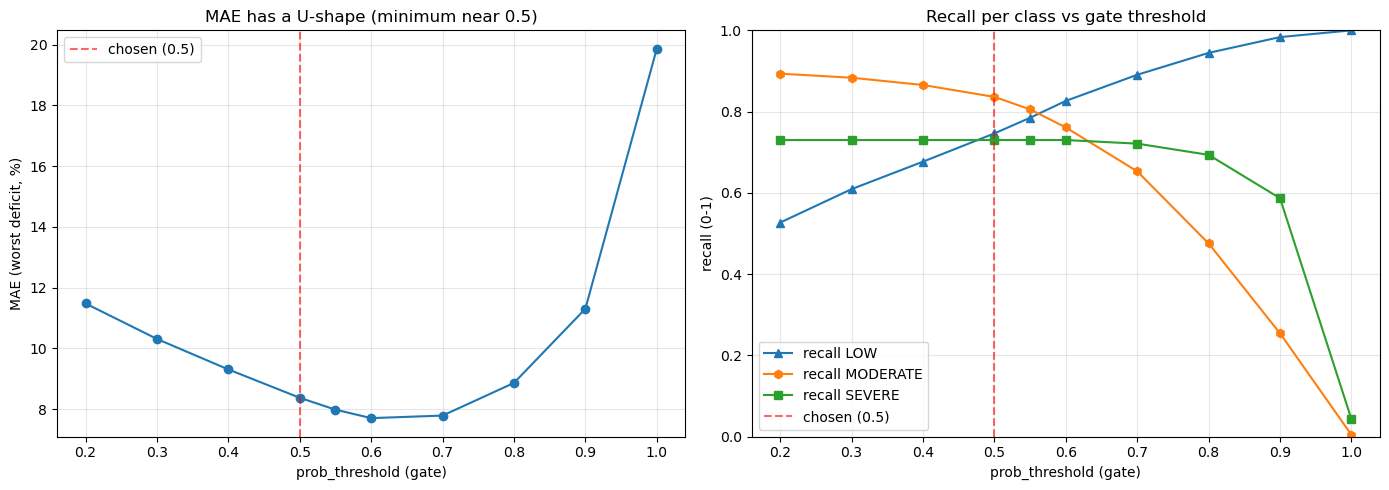

In [19]:
true_worst_va = worst_deficit({t: va[t].to_numpy() for t in TARGETS})
true_sugg_va = suggestion({t: va[t].to_numpy() for t in TARGETS})

rows = []
for thr in [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0]:
    gated = {t: predict_gated(*models[t], Xva, thr) for t in TARGETS}
    sugg = suggestion(gated)
    mae = mean_absolute_error(true_worst_va, worst_deficit(gated))
    recalls = {}
    for cls in ["LOW", "MODERATE", "SEVERE"]:
        mask = true_sugg_va == cls
        recalls[cls] = (sugg[mask] == cls).mean()
    rows.append([thr, mae, recalls["LOW"], recalls["MODERATE"], recalls["SEVERE"]])

sw = pd.DataFrame(rows, columns=["threshold", "mae_worst",
                                 "recall_LOW", "recall_MODERATE", "recall_SEVERE"])
print(sw.round(3).to_string(index=False))

# Two-panel view: MAE has a U-shape; recall per class stays stable then drops.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sw["threshold"], sw["mae_worst"], "o-", color="C0")
ax1.axvline(0.5, ls="--", color="red", alpha=0.6, label="chosen (0.5)")
ax1.set_xlabel("prob_threshold (gate)")
ax1.set_ylabel("MAE (worst deficit, %)")
ax1.set_title("MAE has a U-shape (minimum near 0.5)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(sw["threshold"], sw["recall_LOW"], "^-", color="C0", label="recall LOW")
ax2.plot(sw["threshold"], sw["recall_MODERATE"], "h-", color="C1", label="recall MODERATE")
ax2.plot(sw["threshold"], sw["recall_SEVERE"], "s-", color="C2", label="recall SEVERE")
ax2.axvline(0.5, ls="--", color="red", alpha=0.6, label="chosen (0.5)")
ax2.set_xlabel("prob_threshold (gate)")
ax2.set_ylabel("recall (0-1)")
ax2.set_ylim(0, 1)
ax2.set_title("Recall per class vs gate threshold")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


## 4. Cross-validation on train (more robust tuning)

The 10% validation set is small (~24 farms), so a single split can be noisy. To
choose the gate threshold more robustly, we run **5-fold CV on the train set**
(grouped by farm). The test set is still NOT touched.



5-fold CV on train (gate sweep):
 threshold  cv_mae_worst  cv_recall_SEVERE
      0.20        12.156             0.664
      0.30        10.941             0.664
      0.40         9.798             0.664
      0.50         8.912             0.664
      0.55         8.594             0.664
      0.60         8.444             0.664
      0.70         8.620             0.656
      0.80         9.660             0.627
      0.90        12.211             0.503
      1.00        19.359             0.014


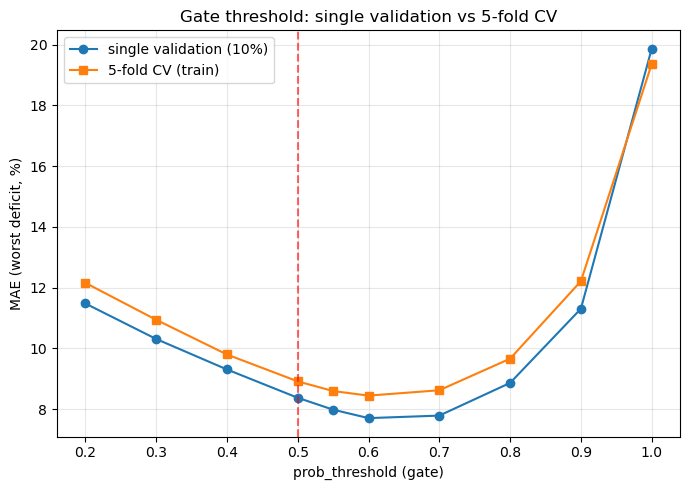

In [20]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)
Xtr_all = tr[FEATURES].to_numpy()

thresholds = [0.2, 0.3, 0.4, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0]
mae_cv = {thr: [] for thr in thresholds}
rec_cv = {thr: [] for thr in thresholds}

for tr_idx, va_idx in gkf.split(tr, groups=tr["point_id"]):
    Xf_tr = Xtr_all[tr_idx]
    Xf_va = Xtr_all[va_idx]
    fold_gated = {}
    for t in TARGETS:
        clf, reg = fit_hurdle(Xf_tr, tr[t].to_numpy()[tr_idx])
        p = clf.predict_proba(Xf_va)[:, 1]
        mu = reg.predict(Xf_va)
        fold_gated[t] = (p, mu)   # keep P and magnitude, apply the gate later

    true_worst_f = worst_deficit({t: tr[t].to_numpy()[va_idx] for t in TARGETS})
    true_sugg_f = suggestion({t: tr[t].to_numpy()[va_idx] for t in TARGETS})

    for thr in thresholds:
        gated = {t: gated_prediction(fold_gated[t][0], fold_gated[t][1], thr)
                 for t in TARGETS}
        sugg = suggestion(gated)
        mae_cv[thr].append(mean_absolute_error(true_worst_f, worst_deficit(gated)))
        mask = true_sugg_f == "SEVERE"
        rec_cv[thr].append((sugg[mask] == "SEVERE").mean())

cv_rows = [[thr, np.mean(mae_cv[thr]), np.mean(rec_cv[thr])] for thr in thresholds]
cv_df = pd.DataFrame(cv_rows, columns=["threshold", "cv_mae_worst", "cv_recall_SEVERE"])
print("5-fold CV on train (gate sweep):")
print(cv_df.round(3).to_string(index=False))

# Compare: single validation (10%) vs 5-fold CV (train) for the MAE U-shape.
plt.figure(figsize=(7, 5))
plt.plot(sw["threshold"], sw["mae_worst"], "o-", label="single validation (10%)")
plt.plot(cv_df["threshold"], cv_df["cv_mae_worst"], "s-", label="5-fold CV (train)")
plt.axvline(0.5, ls="--", color="red", alpha=0.6)
plt.xlabel("prob_threshold (gate)")
plt.ylabel("MAE (worst deficit, %)")
plt.title("Gate threshold: single validation vs 5-fold CV")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 5. Report on test (20%), once

The choices are frozen (gate = 0.5, 3 classes). We evaluate on the test set for
the first and only time. This is the honest, unbiased estimate.


MAE / RMSE on test (the final model):
  future_deficit_1m        MAE=  4.37   RMSE= 10.03
  future_deficit_3m        MAE=  5.15   RMSE=  9.57
  future_deficit_6m        MAE=  7.29   RMSE= 11.17


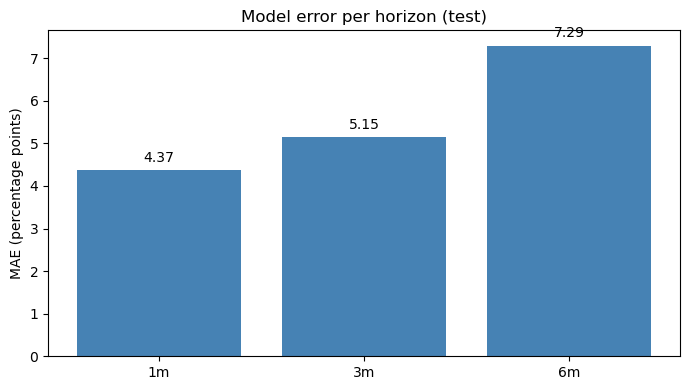


Recall on test (3 classes):
  recall MODERATE  : 0.804
  recall SEVERE    : 0.648

Confusion matrix (row-normalized):
           LOW  MODERATE  SEVERE
LOW       0.79      0.20    0.00
MODERATE  0.15      0.80    0.04
SEVERE    0.00      0.35    0.65


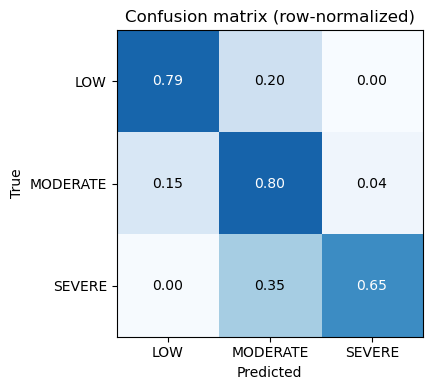

In [21]:
gated_te = {t: predict_gated(*models[t], Xte) for t in TARGETS}

# Regression error (percentage points of deficit).
print("MAE / RMSE on test (the final model):")
mae_vals, rmse_vals = [], []
for t in TARGETS:
    g = gated_te[t]
    m = mean_absolute_error(te[t], g)
    r = rmse(te[t], g)
    mae_vals.append(m); rmse_vals.append(r)
    print(f"  {t:<24} MAE={m:6.2f}   RMSE={r:6.2f}")

# Bar chart of the error per horizon.
horizons = ["1m", "3m", "6m"]
x = np.arange(len(horizons))
plt.figure(figsize=(7, 4))
plt.bar(x, mae_vals, color="steelblue")
plt.xticks(x, horizons)
plt.ylabel("MAE (percentage points)")
plt.title("Model error per horizon (test)")
for i, v in enumerate(mae_vals):
    plt.text(i, v + 0.2, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

# Decision quality: recall of the classes that justify irrigation.
true_sugg_te = suggestion({t: te[t].to_numpy() for t in TARGETS})
pred_sugg_te = suggestion(gated_te)
print()
print("Recall on test (3 classes):")
for cls in ["MODERATE", "SEVERE"]:
    mask = true_sugg_te == cls
    print(f"  recall {cls:<10}: {(pred_sugg_te[mask] == cls).mean():.3f}")

# Confusion matrix (row-normalized = recall per class).
cm = confusion_matrix(true_sugg_te, pred_sugg_te, labels=CLASS_NAMES)
cmn = cm / cm.sum(axis=1, keepdims=True)
print()
print("Confusion matrix (row-normalized):")
print(pd.DataFrame(cmn, index=CLASS_NAMES, columns=CLASS_NAMES).round(2).to_string())

plt.figure(figsize=(5, 4))
plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(3), CLASS_NAMES)
plt.yticks(range(3), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                 color="white" if cmn[i, j] > 0.5 else "black")
plt.title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()



## 6. Feature importance

Which features drive each stage? We average the importance of the stage-1
classifier and the stage-2 regressor across the 3 horizons.


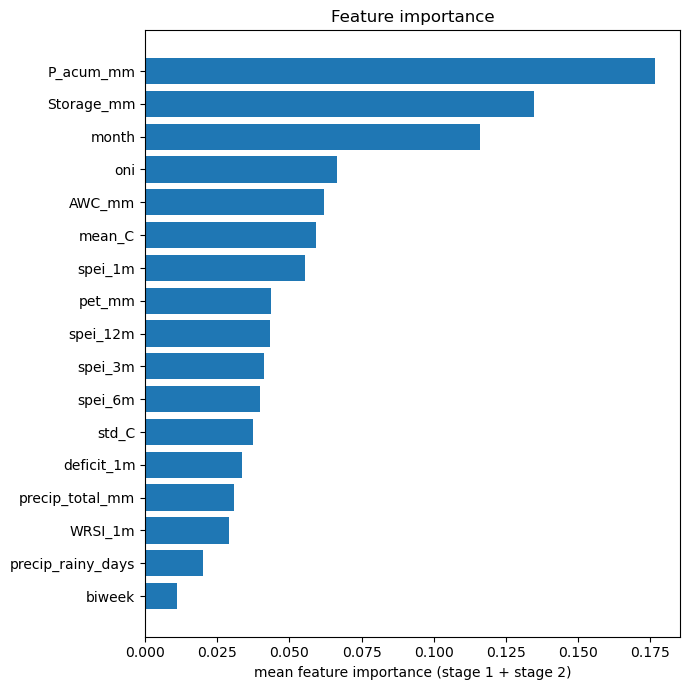

In [22]:
imp = {}
for t in TARGETS:
    clf, reg = models[t]
    imp[t] = (clf.feature_importances_ + reg.feature_importances_) / 2

imp_df = pd.DataFrame(imp, index=FEATURES)
imp_df["mean"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("mean", ascending=False)

plt.figure(figsize=(7, 7))
plt.barh(imp_df.index[::-1], imp_df["mean"][::-1])
plt.xlabel("mean feature importance (stage 1 + stage 2)")
plt.title("Feature importance")
plt.tight_layout()
plt.show()



## 7. Save the final model (100% of data) + usage example

For deployment we retrain the hurdle on ALL the data (the test metric in section
5 is the honest, unbiased estimate; the deployed model sees everything). The 6
models are saved with `joblib`, plus a `manifest.json` with the configuration.



In [23]:
import json
import joblib

MODEL_DIR = ML_DIR / "hurdle_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

X_all = df[FEATURES]
models_meta = {}
for t in TARGETS:
    clf, reg = fit_hurdle(X_all, df[t].to_numpy())
    joblib.dump(clf, MODEL_DIR / f"clf_{t}.joblib")
    joblib.dump(reg, MODEL_DIR / f"reg_{t}.joblib")
    models_meta[t] = {"classifier": f"clf_{t}.joblib", "regressor": f"reg_{t}.joblib"}
    print(f"saved {t}")

manifest = {
    "model_type": "hurdle",
    "crop": "cacao_ccn51",
    "features": FEATURES,
    "targets": TARGETS,
    "deficit_threshold": 0.0,
    "prob_threshold": PROB_THRESHOLD,
    "class_thresholds": CLASS_THRESHOLDS,
    "class_names": CLASS_NAMES,
    "classifier_config": CLASSIFIER_CONFIG,
    "regressor_config": REGRESSOR_CONFIG,
    "models": models_meta,
}
with open(MODEL_DIR / "manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)
print("manifest saved to", MODEL_DIR / "manifest.json")



saved future_deficit_1m
saved future_deficit_3m
saved future_deficit_6m
manifest saved to /home/wmlegion/Documents/github/ALSRS/ml/hurdle_models/manifest.json


In [25]:
def predict_hurdle(X, prob_threshold=PROB_THRESHOLD,
                   class_thresholds=CLASS_THRESHOLDS, class_names=CLASS_NAMES):
    """17 features in -> gated deficits + suggestion (3 classes)."""
    X = np.asarray(X)
    preds = {}
    for t in TARGETS:
        clf = joblib.load(MODEL_DIR / f"clf_{t}.joblib")
        reg = joblib.load(MODEL_DIR / f"reg_{t}.joblib")
        p = clf.predict_proba(X)[:, 1]
        mu = reg.predict(X)
        preds[t] = gated_prediction(p, mu, prob_threshold)

    out = pd.DataFrame(preds)
    worst = out[TARGETS].max(axis=1).to_numpy()
    idx = np.searchsorted(class_thresholds, worst, side="left")
    out["suggestion"] = [class_names[i] for i in idx]
    return out


# Usage example (in-sample sanity check: the model saw these rows).
demo = predict_hurdle(df[FEATURES].iloc[:10])
print(demo.round(2).to_string())



   future_deficit_1m  future_deficit_3m  future_deficit_6m suggestion
0              65.93              65.10              36.60     SEVERE
1              93.75              67.29              35.22     SEVERE
2              90.52              49.00              28.28     SEVERE
3              68.00              38.34              19.00     SEVERE
4              36.53              23.76              13.58   MODERATE
5              42.02              15.67              10.88   MODERATE
6              32.80              12.75               7.91   MODERATE
7              11.47               4.09               5.53        LOW
8               0.00               0.00               0.00        LOW
9               0.00               0.00               0.00        LOW


## Summary

- **Train 70%** -> fit the hurdle. **Validation 10%** -> tune the gate threshold
  (0.5). **Test 20%** -> report once.
- The final model is the **hurdle with gate 0.5 and 3 classes**
  (LOW / MODERATE / SEVERE), validated with an honest, untouched test set.

